# 07 — La décision du seuil d'abstention : toutes les données pour trancher

**Le score** : quand un élève pose une question, on la compare à chaque fiche de la bibliothèque — le score (similarité cosinus, entre 0 et 1) dit à quel point la meilleure fiche « parle de la même chose » que la question. **Le seuil** : en dessous d'un score choisi, l'agent s'abstient de citer le corpus (il garde les stats Lichess et le moteur, qui ne mentent jamais).

Arbitrage produit : seuil **haut** = prudent, mais risque de priver une vraie question de ses fiches ; seuil **bas** = généreux, mais laisse passer des fiches hors sujet **citées en sources** (mesuré de bout en bout au notebook 05 : piège scandinave → 5 fiches adjacentes citées).

Ici : les 25 questions du gold set passent par le **chemin de production** (`/vector-search` : préfixe d'instruction, collection openings_kb, filtre ECO pour les positions) — on relève le score de la meilleure fiche de chacune, puis on balaie tous les seuils possibles.

In [1]:
import httpx
import yaml

API = "http://localhost:8000/api/v1"
gold = yaml.safe_load(open("../evaluation/gold_set.yml"))

cas = (
    [{"nom": d["q"], "type": "légitime", "q": d["q"], "eco": None} for d in gold["directes"]]
    + [{"nom": f"[position] {p['opening_name']}", "type": "légitime",
        "q": f"Idées principales et plans de l'ouverture {p['opening_name']}", "eco": p["eco"]}
       for p in gold["par_position"]]
    + [{"nom": p["q"], "type": "piège", "q": p["q"], "eco": None} for p in gold["pieges"]]
)

for c in cas:
    params = {"q": c["q"], "k": 5} | ({"eco": c["eco"]} if c["eco"] else {})
    hits = httpx.get(f"{API}/vector-search", params=params, timeout=30).json()["results"]
    c["score"] = round(hits[0]["score"], 3) if hits else 0.0
    c["rayon"] = hits[0]["ouverture"] if hits else "—"

for c in sorted(cas, key=lambda c: c["score"]):
    print(f"{c['score']:.3f}  {'🚫' if c['type'] == 'piège' else '✅'}  {c['nom'][:64]}")

0.486  🚫  Quelle est la meilleure recette de crêpes bretonnes ?
0.514  🚫  Explique-moi la règle du hors-jeu au football.
0.548  🚫  Qui a gagné le championnat du monde d'échecs en 1972 ?
0.618  ✅  What does White aim for in the English Opening?
0.619  🚫  Quelles sont les idées de la défense scandinave ?
0.641  ✅  [position] Ruy Lopez
0.659  🚫  Comment jouer le gambit du roi ?
0.663  ✅  Pourquoi le fou vise-t-il f7 dans la partie italienne ?
0.682  ✅  [position] Queen's Gambit
0.698  ✅  What are the main lines of the Sicilian Defence?
0.698  ✅  Quels sont les plans des Noirs dans la défense est-indienne ?
0.699  ✅  Pourquoi jouer le fou en b5 dans la partie espagnole ?
0.708  ✅  [position] French Defense
0.733  ✅  Comment répondre à la partie anglaise avec les Noirs ?
0.756  ✅  [position] Italian Game
0.769  ✅  What is the main idea behind the Caro-Kann Defence?
0.779  ✅  Quelle est la structure de pions typique de la défense française
0.781  ✅  [position] Sicilian Defense
0.793  ✅  Quel

## La photo : où tombe chaque question, et où couperaient les seuils candidats

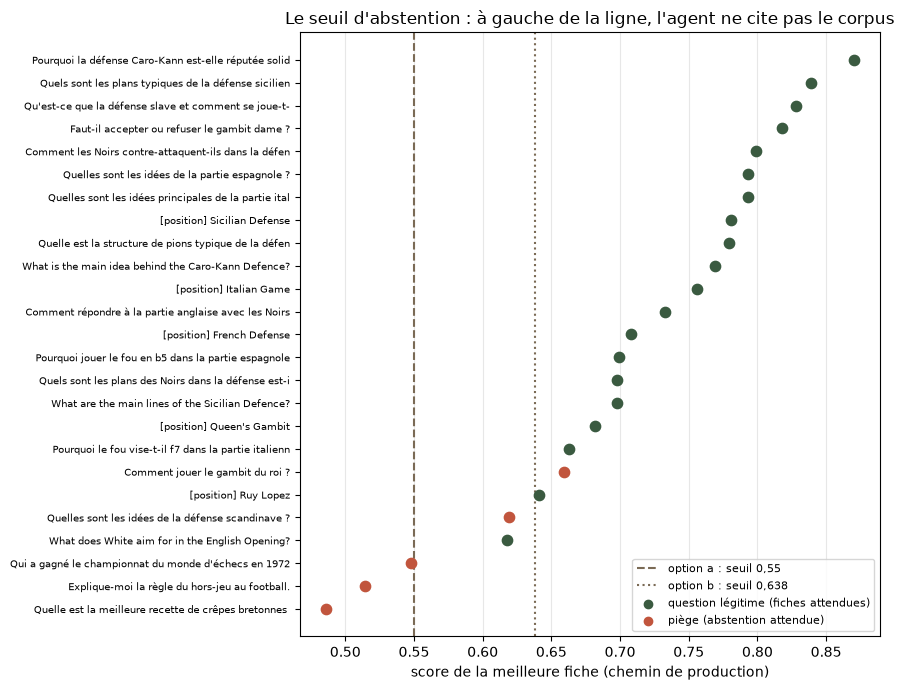

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt

tries = sorted(cas, key=lambda c: c["score"])
couleurs = {"légitime": "#3a5a40", "piège": "#c1553d"}
fig, ax = plt.subplots(figsize=(9, 7))
for i, c in enumerate(tries):
    ax.scatter(c["score"], i, color=couleurs[c["type"]], s=55, zorder=3)
ax.set_yticks(range(len(tries)), [c["nom"][:52] for c in tries], fontsize=7)
for seuil, style, nom in [(0.55, "--", "option a : seuil 0,55"), (0.638, ":", "option b : seuil 0,638")]:
    ax.axvline(seuil, color="#7a6a55", linestyle=style, label=nom)
ax.scatter([], [], color=couleurs["légitime"], label="question légitime (fiches attendues)")
ax.scatter([], [], color=couleurs["piège"], label="piège (abstention attendue)")
ax.set_xlabel("score de la meilleure fiche (chemin de production)")
ax.set_title("Le seuil d'abstention : à gauche de la ligne, l'agent ne cite pas le corpus")
ax.legend(loc="lower right", fontsize=8)
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(Path("../notebooks/figures/07-decision-seuil.png"), dpi=150)
plt.show()

## Le balayage : ce que chaque seuil coûte (légitimes privées de fiches) et rapporte (pièges bloqués)

In [3]:
legitimes = [c for c in cas if c["type"] == "légitime"]
pieges = [c for c in cas if c["type"] == "piège"]

print(f"{'seuil':>6} | {'pièges bloqués':>14} | {'légitimes privées de fiches':>27}")
for seuil in [0.45, 0.50, 0.55, 0.58, 0.60, 0.62, 0.638, 0.66, 0.70]:
    bloques = sum(1 for c in pieges if c["score"] < seuil)
    privees = [c["nom"][:44] for c in legitimes if c["score"] < seuil]
    print(f"{seuil:>6} | {bloques:>10}/5    | {len(privees):>2}  {'; '.join(privees)}")

print("\nZone de recouvrement (l'endroit où AUCUN seuil ne sépare proprement) :")
for c in sorted(cas, key=lambda c: c["score"]):
    if 0.55 <= c["score"] <= 0.70:
        print(f"  {c['score']:.3f}  {'🚫' if c['type'] == 'piège' else '✅'}  {c['nom'][:60]}")

 seuil | pièges bloqués | légitimes privées de fiches
  0.45 |          0/5    |  0  
   0.5 |          1/5    |  0  
  0.55 |          3/5    |  0  
  0.58 |          3/5    |  0  
   0.6 |          3/5    |  0  
  0.62 |          4/5    |  1  What does White aim for in the English Openi
 0.638 |          4/5    |  1  What does White aim for in the English Openi
  0.66 |          5/5    |  2  What does White aim for in the English Openi; [position] Ruy Lopez
   0.7 |          5/5    |  7  Pourquoi le fou vise-t-il f7 dans la partie ; What are the main lines of the Sicilian Defe; Pourquoi jouer le fou en b5 dans la partie e; Quels sont les plans des Noirs dans la défen; What does White aim for in the English Openi; [position] Ruy Lopez; [position] Queen's Gambit

Zone de recouvrement (l'endroit où AUCUN seuil ne sépare proprement) :
  0.618  ✅  What does White aim for in the English Opening?
  0.619  🚫  Quelles sont les idées de la défense scandinave ?
  0.641  ✅  [position] Ruy Lopez


## Lecture pour la décision

- Un seuil **ne peut pas** séparer proprement les deux familles (mesuré depuis le notebook 04) : le piège « domaine adjacent » (scandinave, gambit du roi) ressemble VRAIMENT au corpus — l'embedding fait son travail, c'est la connaissance qui manque.
- Le seuil achète donc un **compromis**, pas une garantie ; ce qu'il ne bloque pas, la **règle d'honnêteté du prompt** doit le couvrir (défense en profondeur) — et le LLM ne peut de toute façon pas citer ce que le code ne lui transmet pas : couper les fiches sous le seuil supprime **mécaniquement** les citations trompeuses mesurées au notebook 05.
- Les trois options sur la table : **(a)** seuil bas ~0,55 — aucune légitime sacrifiée, bloque les pièges grossiers, le prompt gère l'adjacent ; **(b)** seuil au point médian mesuré ~0,638 — bloque plus de pièges mais commence à priver des légitimes ; **(c)** pas de seuil — tout repose sur le prompt, les citations trompeuses restent.

La décision est **produit** (elle appartient à Richard) ; ce notebook fournit les chiffres exacts de chaque option sur le gold set figé.